# 📊 Day 12 — Data Cleaning
### 100 Days of Data Science | by Shoaib Aslam

---

## Table of Contents

1️⃣ What is Data Cleaning  
2️⃣ Why Data Cleaning Matters  
3️⃣ Loading the Dataset  
4️⃣ Handling Missing Values  
5️⃣ Removing Duplicates  
6️⃣ Fixing Data Types  
7️⃣ Renaming Columns  
8️⃣ Handling Outliers  
9️⃣ Standardizing Text Data  
🔟 When to Use What  

---
## 1️⃣ What is Data Cleaning?

Data Cleaning is the process of **fixing or removing incorrect, corrupted, duplicate, or incomplete data** from a dataset.

Real-world data is messy. It comes with:
- Missing values
- Duplicate rows
- Wrong data types
- Inconsistent text (uppercase, lowercase, extra spaces)
- Outliers that don't belong

> **Rule of thumb:** Data scientists spend 80% of their time cleaning data and 20% analyzing it.

---
## 2️⃣ Why Data Cleaning Matters?

| Dirty Data Problem | Impact |
|--------------------|--------|
| Missing values | Model crashes or gives wrong results |
| Duplicate rows | Analysis becomes inflated and misleading |
| Wrong data types | Calculations fail silently |
| Inconsistent text | Same category treated as multiple categories |
| Outliers | Mean and standard deviation become unreliable |

Clean data = reliable analysis = trustworthy decisions.

---
## 3️⃣ Loading the Dataset

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Loading the Winemag dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [3]:
# Quick overview
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst look at missing values:\n", df.isnull().sum())

Shape: (129971, 13)

Data Types:
 country                   object
description               object
designation               object
points                     int64
price                    float64
province                  object
region_1                  object
region_2                  object
taster_name               object
taster_twitter_handle     object
title                     object
variety                   object
winery                    object
dtype: object

First look at missing values:
 country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64


---
## 4️⃣ Handling Missing Values

Missing values are the most common data quality issue. There are three ways to handle them — drop, fill, or impute.

In [4]:
# Check missing values count and percentage
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})
missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
region_2,79460,61.136715
designation,37465,28.825661
taster_twitter_handle,31213,24.015357
taster_name,26244,20.192197
region_1,21247,16.347493
price,8996,6.921544
country,63,0.048472
province,63,0.048472
variety,1,0.000769


In [5]:
# Method 1 — Drop rows where critical column is missing
df_cleaned = df.dropna(subset=['country', 'variety'])
print("After dropping missing country/variety:", df_cleaned.shape)

After dropping missing country/variety: (129907, 13)


In [6]:
# Method 2 — Fill numerical missing values with median
df_cleaned['price'] = df_cleaned['price'].fillna(df_cleaned['price'].median())
print("Price missing values:", df_cleaned['price'].isnull().sum())

Price missing values: 0


C:\Users\aslam\AppData\Local\Temp\ipykernel_3916\864352722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['price'] = df_cleaned['price'].fillna(df_cleaned['price'].median())


In [7]:
# Method 3 — Fill categorical missing values with 'Unknown'
df_cleaned['region_1'] = df_cleaned['region_1'].fillna('Unknown')
df_cleaned['region_2'] = df_cleaned['region_2'].fillna('Unknown')
df_cleaned['designation'] = df_cleaned['designation'].fillna('Unknown')
print("Missing values after cleaning:\n", df_cleaned.isnull().sum())

Missing values after cleaning:
 country                      0
description                  0
designation                  0
points                       0
price                        0
province                     0
region_1                     0
region_2                     0
taster_name              26243
taster_twitter_handle    31212
title                        0
variety                      0
winery                       0
dtype: int64


C:\Users\aslam\AppData\Local\Temp\ipykernel_3916\4145668978.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['region_1'] = df_cleaned['region_1'].fillna('Unknown')
C:\Users\aslam\AppData\Local\Temp\ipykernel_3916\4145668978.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['region_2'] = df_cleaned['region_2'].fillna('Unknown')
C:\Users\aslam\AppData\Local\Temp\ipykernel_3916\4145668978.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

#### 💡 Tip

| Situation | Best Approach |
|-----------|---------------|
| Critical column missing | Drop the row |
| Numerical column | Fill with median (robust to outliers) |
| Categorical column | Fill with mode or 'Unknown' |
| More than 50% missing | Consider dropping the entire column |

---
## 5️⃣ Removing Duplicates

Duplicate rows inflate counts and skew averages — always check for them.

In [8]:
# Check for duplicate rows
print("Total duplicate rows:", df_cleaned.duplicated().sum())

Total duplicate rows: 9979


In [9]:
# View duplicate rows (if any)
df_cleaned[df_cleaned.duplicated()]

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
2408,US,"This is weighty, creamy and medium to full in ...",Unknown,85,14.0,California,North Coast,North Coast,Virginie Boone,@vboone,Souverain 2010 Chardonnay (North Coast),Chardonnay,Souverain
2409,Italy,There's a touch of toasted almond at the start...,Sallier de la Tour,85,13.0,Sicily & Sardinia,Sicilia,Unknown,NaN,NaN,Tasca d'Almerita 2011 Sallier de la Tour Grill...,Grillo,Tasca d'Almerita
2410,Chile,Lightly herbal strawberry and raspberry aromas...,Reserve,85,13.0,Maipo Valley,Unknown,Unknown,Michael Schachner,@wineschach,Tres Palacios 2011 Reserve Pinot Noir (Maipo V...,Pinot Noir,Tres Palacios
2412,Italy,The Monica grape often shows a rustic or raw q...,Dolia,85,14.0,Sicily & Sardinia,Monica di Sardegna,Unknown,NaN,NaN,Cantine di Dolianova 2010 Dolia (Monica di Sa...,Monica,Cantine di Dolianova
2413,France,"Fruity and lightly herbaceous, this has fine t...",La Fleur d'Amélie,85,15.0,Bordeaux,Bordeaux Blanc,Unknown,Roger Voss,@vossroger,Château de Sours 2011 La Fleur d'Amélie (Bord...,Bordeaux-style White Blend,Château de Sours
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129879,US,"This wine is a blend of 45% Grenache, 37% Syra...",Metis,90,20.0,Washington,Columbia Valley (WA),Columbia Valley,Sean P. Sullivan,@wawinereport,Maison Bleue 2013 Metis Red (Columbia Valley (...,Red Blend,Maison Bleue
129880,US,Apple blossom intrigues on the nose of this li...,Unknown,90,20.0,California,Russian River Valley,Sonoma,Virginie Boone,@vboone,Martin Ray 2015 Chardonnay (Russian River Valley),Chardonnay,Martin Ray
129881,Spain,This Verdejo smells like citrus fruits and wil...,Unknown,90,19.0,Northern Spain,Rueda,Unknown,Michael Schachner,@wineschach,Martinsancho 2015 Verdejo (Rueda),Verdejo,Martinsancho
129882,US,"This wine is mostly Cabernet Sauvignon (78%), ...",Reserve,90,60.0,Washington,Columbia Valley (WA),Columbia Valley,Sean P. Sullivan,@wawinereport,Matthews 2012 Reserve Red (Columbia Valley (WA)),Bordeaux-style Red Blend,Matthews


In [10]:
# Remove duplicate rows
df_cleaned = df_cleaned.drop_duplicates()
print("Shape after removing duplicates:", df_cleaned.shape)

Shape after removing duplicates: (119928, 13)


In [11]:
# Check duplicates based on specific columns
print("Duplicate titles:", df_cleaned.duplicated(subset=['title']).sum())

# Remove duplicates based on title column
df_cleaned = df_cleaned.drop_duplicates(subset=['title'])
print("Shape after removing duplicate titles:", df_cleaned.shape)

Duplicate titles: 1148
Shape after removing duplicate titles: (118780, 13)


---
## 6️⃣ Fixing Data Types

Wrong data types cause silent errors in calculations and comparisons.

In [12]:
# Check current data types
df_cleaned.dtypes

country                   object
description               object
designation               object
points                     int64
price                    float64
province                  object
region_1                  object
region_2                  object
taster_name               object
taster_twitter_handle     object
title                     object
variety                   object
winery                    object
dtype: object

In [13]:
# Convert price to integer (after filling missing values)
df_cleaned['price'] = df_cleaned['price'].astype(int)
print("Price dtype:", df_cleaned['price'].dtype)

Price dtype: int64


In [14]:
# Convert categorical columns to 'category' type (saves memory)
df_cleaned['country'] = df_cleaned['country'].astype('category')
df_cleaned['variety'] = df_cleaned['variety'].astype('category')

print("Memory usage before vs after:")
print(df_cleaned[['country', 'variety']].dtypes)

Memory usage before vs after:
country    category
variety    category
dtype: object


---
## 7️⃣ Renaming Columns

Clean column names make your code more readable and easier to work with.

In [15]:
# Check current column names
print(df_cleaned.columns.tolist())

['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'variety', 'winery']


In [16]:
# Rename specific columns for clarity
df_cleaned = df_cleaned.rename(columns={
    'points': 'review_points',
    'price': 'price_usd',
    'taster_name': 'reviewer',
    'taster_twitter_handle': 'reviewer_twitter'
})

df_cleaned.columns.tolist()

['country',
 'description',
 'designation',
 'review_points',
 'price_usd',
 'province',
 'region_1',
 'region_2',
 'reviewer',
 'reviewer_twitter',
 'title',
 'variety',
 'winery']

In [17]:
# Make all column names lowercase and replace spaces with underscores
df_cleaned.columns = df_cleaned.columns.str.lower().str.replace(' ', '_')
print("Cleaned column names:", df_cleaned.columns.tolist())

Cleaned column names: ['country', 'description', 'designation', 'review_points', 'price_usd', 'province', 'region_1', 'region_2', 'reviewer', 'reviewer_twitter', 'title', 'variety', 'winery']


---
## 8️⃣ Handling Outliers

Outliers are extreme values that distort your analysis. The IQR method is the most reliable way to detect them.

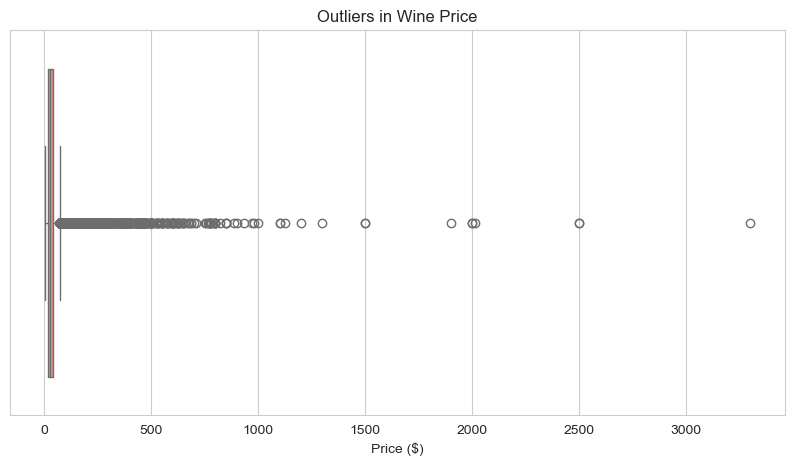

In [18]:
# Visualize outliers in price
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_cleaned['price_usd'], color='salmon')
plt.title("Outliers in Wine Price")
plt.xlabel("Price ($)")
plt.show()

In [19]:
# IQR method to find outlier boundaries
Q1 = df_cleaned['price_usd'].quantile(0.25)
Q3 = df_cleaned['price_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Lower Bound: {lower_bound} | Upper Bound: {upper_bound}")

Q1: 18.0 | Q3: 40.0 | IQR: 22.0
Lower Bound: -15.0 | Upper Bound: 73.0


In [20]:
# Count and remove outliers
outliers = df_cleaned[(df_cleaned['price_usd'] < lower_bound) | (df_cleaned['price_usd'] > upper_bound)]
print(f"Total Outliers: {len(outliers)}")

df_no_outliers = df_cleaned[(df_cleaned['price_usd'] >= lower_bound) & (df_cleaned['price_usd'] <= upper_bound)]
print(f"Shape after removing outliers: {df_no_outliers.shape}")

Total Outliers: 8465
Shape after removing outliers: (110315, 13)


---
## 9️⃣ Standardizing Text Data

Inconsistent text is a silent killer — 'USA', 'usa', and ' USA ' are treated as three different values.

In [21]:
# Check unique country values (sample)
df_cleaned['country'].value_counts().head(10)

country
US           50229
France       19739
Italy        17805
Spain         6021
Portugal      5222
Chile         4177
Argentina     3543
Austria       3022
Australia     2183
Germany       1990
Name: count, dtype: int64

In [22]:
# Strip extra whitespace from all string columns
df_cleaned['country'] = df_cleaned['country'].astype(str).str.strip()
df_cleaned['variety'] = df_cleaned['variety'].astype(str).str.strip()
df_cleaned['winery'] = df_cleaned['winery'].astype(str).str.strip()

print("Whitespace stripped from text columns.")

Whitespace stripped from text columns.


In [23]:
# Convert country to title case for consistency
df_cleaned['country'] = df_cleaned['country'].str.title()
df_cleaned['country'].value_counts().head(10)

country
Us           50229
France       19739
Italy        17805
Spain         6021
Portugal      5222
Chile         4177
Argentina     3543
Austria       3022
Australia     2183
Germany       1990
Name: count, dtype: int64

In [24]:
# Final cleaned dataset overview
print("Final Shape:", df_cleaned.shape)
print("\nRemaining Missing Values:\n", df_cleaned.isnull().sum())
df_cleaned.head()

Final Shape: (118780, 13)

Remaining Missing Values:
 country                 0
description             0
designation             0
review_points           0
price_usd               0
province                0
region_1                0
region_2                0
reviewer            24732
reviewer_twitter    29252
title                   0
variety                 0
winery                  0
dtype: int64


,country,description,designation,review_points,price_usd,province,region_1,region_2,reviewer,reviewer_twitter,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,25,Sicily & Sardinia,Etna,Unknown,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15,Douro,Unknown,Unknown,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,Us,"Tart and snappy, the flavors of lime flesh and...",Unknown,87,14,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,Us,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13,Michigan,Lake Michigan Shore,Unknown,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,Us,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


---
## 🔟 When to Use What

| Cleaning Task | Method | When to Use |
|---------------|--------|-------------|
| Missing values — numerical | `fillna(median)` | When column has outliers |
| Missing values — categorical | `fillna('Unknown')` | When category is unknown |
| Missing values — critical | `dropna(subset=[col])` | When row is useless without it |
| Duplicate rows | `drop_duplicates()` | Always check before analysis |
| Wrong data types | `astype()` | After filling all missing values |
| Outliers | IQR method + boxplot | For numerical columns |
| Inconsistent text | `str.strip()`, `str.title()` | For categorical text columns |
| Column names | `rename()`, `str.lower()` | At the start of every project |

---
## 🔑 Key Takeaways

→ Always check `shape`, `dtypes`, and `isnull().sum()` before doing anything  
→ Never drop missing values blindly — understand why they are missing first  
→ Use **median** to fill numerical missing values — it is robust to outliers  
→ Duplicate rows silently inflate your analysis — always remove them  
→ Wrong data types cause silent calculation errors — fix them early  
→ Inconsistent text ('USA' vs 'usa') creates fake categories — always standardize  
→ Data cleaning is not a one-time step — it is an ongoing process

---
## 📁 Connect & Follow the Journey

| Platform | Link |
|----------|------|
| 🐙 GitHub | https://github.com/imshoaibaslam/100-Days-of-Data-Science |
| 📊 Kaggle | https://www.kaggle.com/shoaib32922 |

---
*Day 12 of 100 — Keep Learning, Keep Building 🚀*